In [331]:
import math

import cv2
import matplotlib.pyplot as plt


def zeige_bild(bilder, titel=None, texte=None, spalten=None, figsize=None, cmap="gray"):
    if not isinstance(bilder, (list, tuple)):
        bilder = [bilder]

    anzahl = len(bilder)

    if titel is None:
        titel = ["Bild"] * anzahl
    elif isinstance(titel, str):
        titel = [titel]
    else:
        titel = list(titel)

    if texte is None:
        texte = [""] * anzahl
    elif isinstance(texte, str):
        texte = [texte]
    else:
        texte = list(texte)

    titel += [""] * (anzahl - len(titel))
    texte += [""] * (anzahl - len(texte))

    if spalten is None:
        spalten = min(anzahl, 3)

    zeilen = math.ceil(anzahl / spalten)

    if figsize is None:
        figsize = (5 * spalten, 4 * zeilen)

    fig, axes = plt.subplots(zeilen, spalten, figsize=figsize, sqüeze=False)
    axes = axes.ravel()

    for index, bild in enumerate(bilder):
        ax = axes[index]
        if bild.ndim == 2:
            ax.imshow(bild, cmap=cmap)
        else:
            ax.imshow(bild)
        ax.set_title(titel[index])
        if texte[index]:
            ax.text(0.5, -0.08, texte[index], ha="center", va="top", transform=ax.transAxes)
        ax.axis("off")

    for ax in axes[anzahl:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

image = cv2.imread("bilder/1.jpg")
#image = cv2.imread("bilder/1_mit_münze.jpg")
#image = cv2.imread("bilder/3_mit_münze.jpg")

if image is None:
    raise FileNotFoundError("bilder/1.jpg wurde nicht gefunden")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [332]:
# Schritt 1: Vorverarbeitung bis zum geglätteten und binarisierten Graustufenbild.
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


In [333]:
zeige_bild(
    [image, gray, blurred, binary],
    titel=["Originalbild", "Graustufen", "Geglättet", "Binarisiert"],
    spalten=2,
    figsize=(12, 8),
)


AttributeError: Figure.set() got an unexpected keyword argument 'sqüeze'

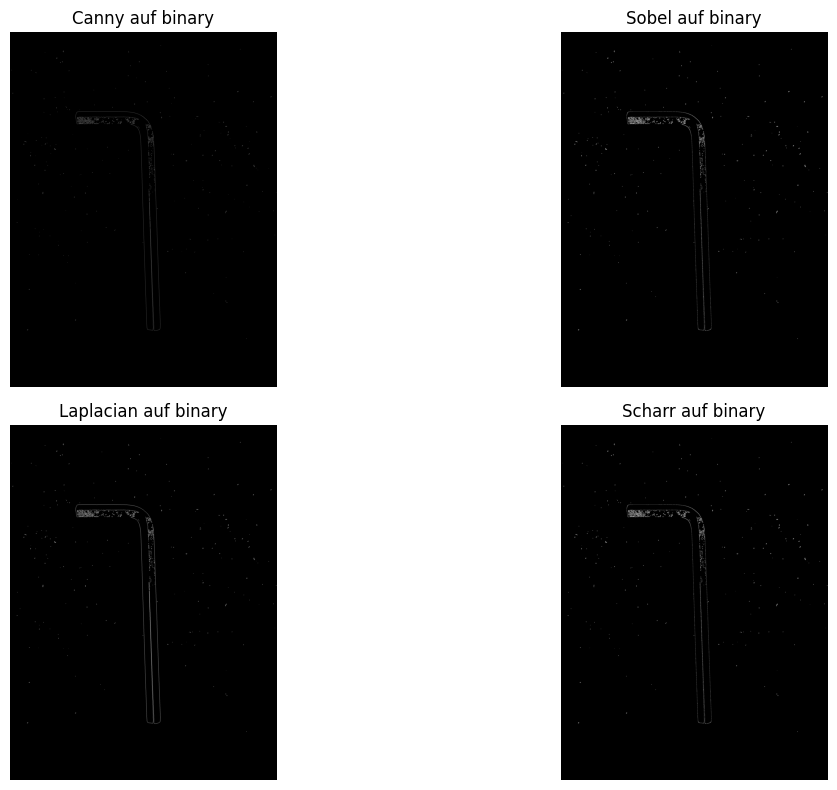

In [ ]:
# Schritt 2: unterschiedliche Kantenerkennungsmethoden auf dem binarisierten Bild vergleichen.
canny_edges = cv2.Canny(binary, threshold1=75, threshold2=200)

sobel_x = cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)
sobel_edges = cv2.convertScaleAbs(cv2.addWeighted(
    cv2.convertScaleAbs(sobel_x), 0.5,
    cv2.convertScaleAbs(sobel_y), 0.5,
    0,
))

laplacian_edges = cv2.convertScaleAbs(cv2.Laplacian(binary, cv2.CV_64F))

scharr_x = cv2.Scharr(binary, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(binary, cv2.CV_64F, 0, 1)
scharr_edges = cv2.convertScaleAbs(cv2.addWeighted(
    cv2.convertScaleAbs(scharr_x), 0.5,
    cv2.convertScaleAbs(scharr_y), 0.5,
    0,
))

zeige_bild(
    [canny_edges, sobel_edges, laplacian_edges, scharr_edges],
    titel=["Canny auf binary", "Sobel auf binary", "Laplacian auf binary", "Scharr auf binary"],
    spalten=2,
    figsize=(14, 8),
)


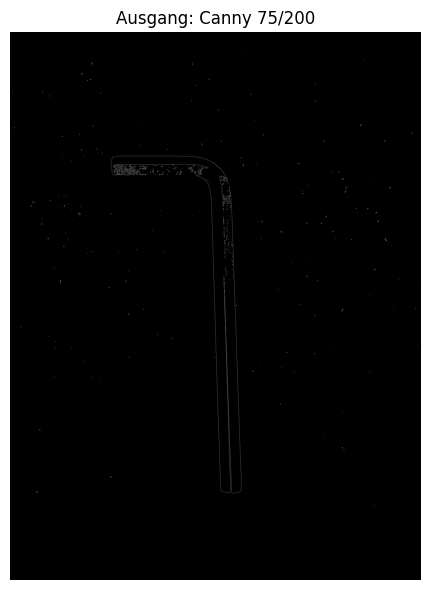

In [ ]:
## Kantenerkennung setzen
selected_edges = canny_edges.copy()
zeige_bild(selected_edges, titel="Ausgang: Canny 75/200", figsize=(8, 6))


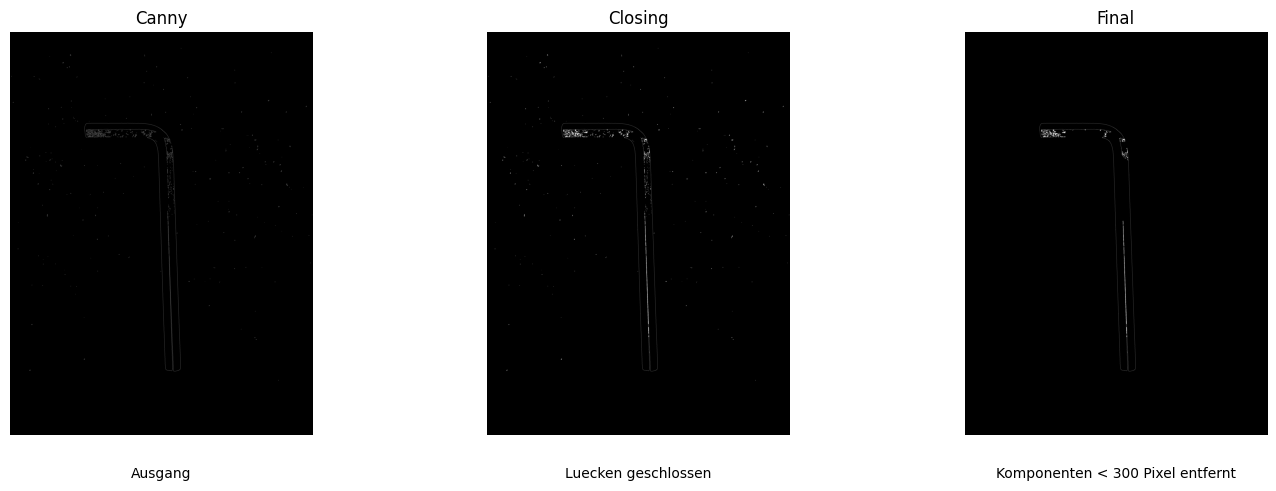

In [ ]:
# Morphologie: kleine Punkte entfernen und wichtige Kanten behalten.
def entferne_kleine_komponenten(binary_image, min_area=300):
    anzahl, labels, stats, _ = cv2.connectedComponentsWithStats(binary_image, connectivity=8)
    result = binary_image.copy() * 0

    for label in range(1, anzahl):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            result[labels == label] = 255

    return result


edges_start = selected_edges.copy()

# 1. Kleine Lücken in den Kanten schliessen.
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges_closed = cv2.morphologyEx(edges_start, cv2.MORPH_CLOSE, kernel_close, iterations=1)

# 2. Nach dem Closing kleine Punkte/Flecken entfernen.
edges_final = entferne_kleine_komponenten(edges_closed, min_area=300)

zeige_bild(
    [edges_start, edges_closed, edges_final],
    titel=["Canny", "Closing", "Final"],
    texte=[
        "Ausgang",
        "Lücken geschlossen",
        "Komponenten < 300 Pixel entfernt",
    ],
    spalten=3,
    figsize=(15, 5),
)


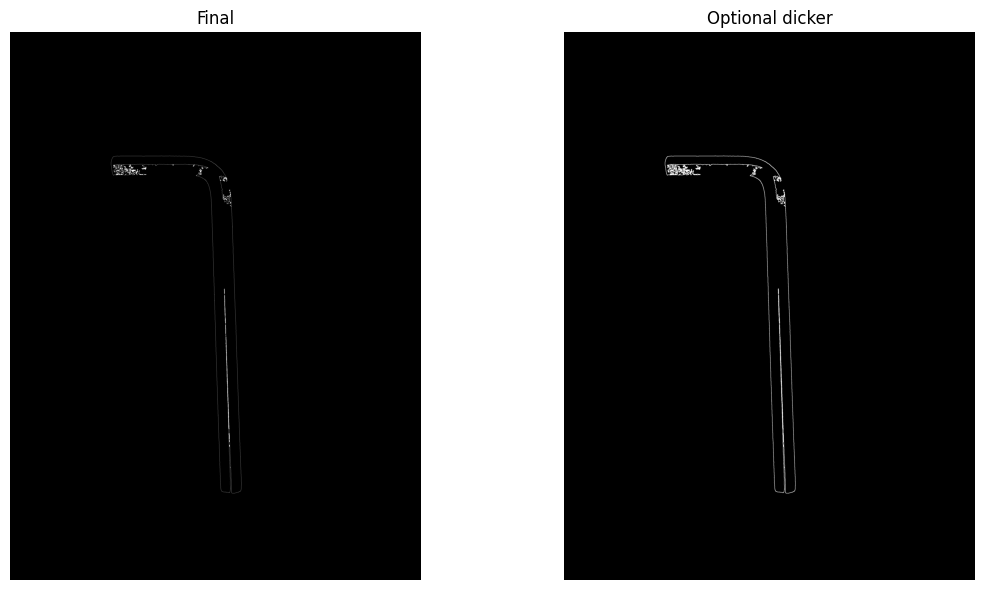

In [ ]:
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# nur fürs angucken
edges_dicker = cv2.dilate(edges_final, kernel_dilate, iterations=1)

zeige_bild(
    [edges_final, edges_dicker],
    titel=["Final", "Optional dicker"],
    figsize=(12, 6),
)


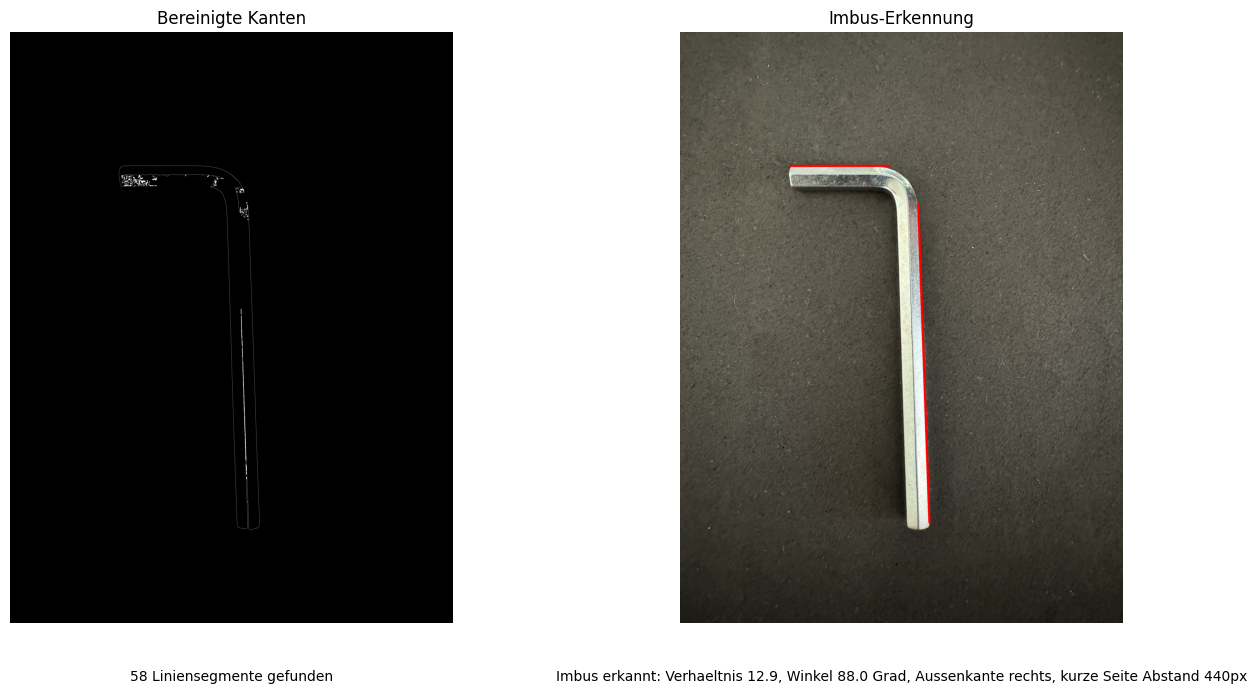

In [ ]:
# Objekterkennung: Imbus-Form über lange + kurze rechtwinklige Kante erkennen.
import numpy as np


def linienwinkel(line):
    x1, y1, x2, y2 = line
    return (math.degrees(math.atan2(y2 - y1, x2 - x1)) + 180) % 180


def linienlänge(line):
    x1, y1, x2, y2 = line
    return math.hypot(x2 - x1, y2 - y1)


def winkeldifferenz(a, b):
    diff = abs(a - b) % 180
    return min(diff, 180 - diff)


def linienmittelpunkt_x(line):
    x1, _, x2, _ = line
    return (x1 + x2) / 2


def punktabstand(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])


def kleinster_endpunktabstand(line_a, line_b):
    punkte_a = [(line_a[0], line_a[1]), (line_a[2], line_a[3])]
    punkte_b = [(line_b[0], line_b[1]), (line_b[2], line_b[3])]
    return min(punktabstand(pa, pb) for pa in punkte_a for pb in punkte_b)


def erweitere_linie_auf_kante(edge_image, line, max_abstand=24):
    x1, y1, x2, y2 = line
    richtung = np.array([x2 - x1, y2 - y1], dtype=np.float64)
    länge = np.linalg.norm(richtung)
    if länge == 0:
        return line

    richtung /= länge
    start = np.array([x1, y1], dtype=np.float64)

    ys, xs = np.nonzero(edge_image)
    punkte = np.column_stack((xs, ys)).astype(np.float64)
    relativ = punkte - start

    projektion = relativ @ richtung
    senkrecht = np.abs(relativ[:, 0] * richtung[1] - relativ[:, 1] * richtung[0])

    # Nur Kantenpunkte nehmen, die nahe an derselben Geraden liegen.
    mask = senkrecht <= max_abstand
    if np.count_nonzero(mask) < 2:
        return line

    linien_projektionen = projektion[mask]

    # Kleine Ausreisser am Rand ignorieren.
    t_min = np.percentile(linien_projektionen, 2)
    t_max = np.percentile(linien_projektionen, 98)

    p_start = start + t_min * richtung
    p_ende = start + t_max * richtung

    hoehe, breite = edge_image.shape
    p_start[0] = np.clip(p_start[0], 0, breite - 1)
    p_start[1] = np.clip(p_start[1], 0, hoehe - 1)
    p_ende[0] = np.clip(p_ende[0], 0, breite - 1)
    p_ende[1] = np.clip(p_ende[1], 0, hoehe - 1)

    return (
        int(round(p_start[0])), int(round(p_start[1])),
        int(round(p_ende[0])), int(round(p_ende[1])),
    )


def finde_imbus_kandidat(edge_image):
    hoehe, breite = edge_image.shape
    diagonale = math.hypot(breite, hoehe)

    lines = cv2.HoughLinesP(
        edge_image,
        rho=1,
        theta=np.pi / 180,
        threshold=80,
        minLineLength=int(diagonale * 0.02),
        maxLineGap=int(diagonale * 0.008),
    )

    if lines is None:
        return None, []

    segmente = []
    for line in lines[:, 0, :]:
        line = tuple(int(valü) for valü in line)
        length = linienlänge(line)
        if length >= diagonale * 0.02:
            segmente.append({
                "line": line,
                "length": length,
                "angle": linienwinkel(line),
            })

    ys, xs = np.nonzero(edge_image)
    if len(xs) > 0:
        objekt_mitte_x = (xs.min() + xs.max()) / 2
        if objekt_mitte_x >= breite / 2:
            ziel_aussen_x = xs.min()
            aussenseite = "links"
        else:
            ziel_aussen_x = xs.max()
            aussenseite = "rechts"
    else:
        ziel_aussen_x = breite / 2
        aussenseite = "unbekannt"

    max_endpunktabstand = diagonale * 0.13
    gültige_paare = []

    for index, first in enumerate(segmente):
        for second in segmente[index + 1:]:
            long_side, short_side = (first, second)
            if second["length"] > first["length"]:
                long_side, short_side = second, first

            ratio = long_side["length"] / max(short_side["length"], 1)
            if not 1.8 <= ratio <= 15.0:
                continü

            angle_diff = winkeldifferenz(long_side["angle"], short_side["angle"])
            if abs(angle_diff - 90) > 20:
                continü

            endpunktabstand = kleinster_endpunktabstand(long_side["line"], short_side["line"])
            if endpunktabstand > max_endpunktabstand:
                continü

            long_aussenabstand = abs(linienmittelpunkt_x(long_side["line"]) - ziel_aussen_x)
            short_aussenabstand = abs(linienmittelpunkt_x(short_side["line"]) - ziel_aussen_x)
            basis_score = long_side["length"] + short_side["length"] - 1.5 * endpunktabstand

            gültige_paare.append({
                "long_side": long_side,
                "short_side": short_side,
                "ratio": ratio,
                "angle_diff": angle_diff,
                "endpunktabstand": endpunktabstand,
                "short_aussenabstand": short_aussenabstand,
                "long_aussenabstand": long_aussenabstand,
                "basis_score": basis_score,
            })

    if not gültige_paare:
        return None, segmente

    # Erst die beste lange Seite wählen. Die kurze Aussenkante darf diese Wahl nicht kippen.
    bestes_langes_paar = max(
        gültige_paare,
        key=lambda pair: (pair["long_side"]["length"], pair["basis_score"]),
    )
    beste_lange_linie = bestes_langes_paar["long_side"]["line"]

    paare_mit_bester_langer_seite = [
        pair for pair in gültige_paare
        if pair["long_side"]["line"] == beste_lange_linie
    ]

    # Zur fest gewählten langen Seite nur die äussere kurze Seite nehmen.
    bester_kandidat = min(
        paare_mit_bester_langer_seite,
        key=lambda pair: (pair["short_aussenabstand"], -pair["basis_score"]),
    )
    bester_kandidat["aussenseite"] = aussenseite
    bester_kandidat["ziel_aussen_x"] = ziel_aussen_x

    return bester_kandidat, segmente


imbus_kandidat, gefundene_linien = finde_imbus_kandidat(edges_final)
imbus_result = image.copy()

if imbus_kandidat is not None:
    for side_name in ["long_side", "short_side"]:
        line = imbus_kandidat[side_name]["line"]
        x1, y1, x2, y2 = erweitere_linie_auf_kante(edges_final, line)
        cv2.line(imbus_result, (x1, y1), (x2, y2), (255, 0, 0), thickness=14)

    text = (
        f"Imbus erkannt: Verhältnis {imbus_kandidat['ratio']:.1f}, "
        f"Winkel {imbus_kandidat['angle_diff']:.1f} Grad, "
        f"Aussenkante {imbus_kandidat['aussenseite']}, "
        f"kurze Seite Abstand {imbus_kandidat['short_aussenabstand']:.0f}px"
    )
else:
    text = "Kein Imbus-Kandidat gefunden"

zeige_bild(
    [edges_final, imbus_result],
    titel=["Bereinigte Kanten", "Imbus-Erkennung"],
    texte=[f"{len(gefundene_linien)} Liniensegmente gefunden", text],
    figsize=(14, 7),
)
